# RAGAS Evaluation — Naive vs Hybrid + Rerank

Compares two retrieval setups on the ground-truth questions:

- **Naive vector** — dense-only similarity search (`bge-m3`), top-k.
- **Hybrid + rerank** — dense + BM25 fused with RRF, then `bge-reranker-v2-m3`.

Answers generated by **OpenAI `gpt-4o-mini`**, scored by an **independent judge** (different model family → no self-grading). Metrics from **RAGAS**.

> ⚠️ **Limited sample — 2 questions only.**
>
> The full 16-question run was cut short by **free-tier LLM-judge rate limits** (both Groq `llama-3.3-70b` and Gemini flash throttle under RAGAS's burst of calls, and a local judge is impractically slow on this CPU-only machine).
>
> These numbers are an **illustrative smoke test, not a statistically meaningful result** — with n=2 a single imperfect answer swings an average sharply. The pipeline supports the full 16; re-run `python -m app.evaluate` with a higher-quota judge to reproduce the complete evaluation.

In [1]:
import json
from pathlib import Path
import pandas as pd

# Works whether the notebook runs from eval/ or the repo root.
_p = Path('results.json')
if not _p.exists():
    _p = Path('eval/results.json')
results = json.loads(_p.read_text(encoding='utf-8'))
print('Generator:', results['generator'])
print('Judge:    ', results['judge'])
print('Questions:', results['num_questions'], '| top-k:', results['top_k'])

Generator: openai/gpt-4o-mini
Judge:     groq/llama-3.3-70b-versatile
Questions: 2 | top-k: 5


## Aggregate metrics (n = 2 — see caveat above)

In [2]:
METRICS = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
naive = results['modes']['naive']['aggregate']
hybrid = results['modes']['hybrid_rerank']['aggregate']

table = pd.DataFrame({
    'naive': [naive[m] for m in METRICS],
    'hybrid+rerank': [hybrid[m] for m in METRICS],
}, index=METRICS)
table['delta'] = table['hybrid+rerank'] - table['naive']
table.round(3)

,naive,hybrid+rerank,delta
faithfulness,1.000,0.750,-0.250
answer_relevancy,0.963,0.944,-0.019
context_precision,1.000,0.902,-0.098
context_recall,1.000,1.000,0.000


## Comparison chart

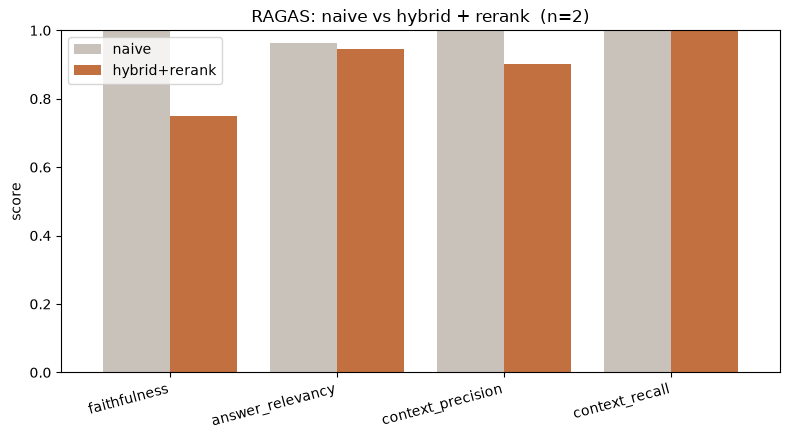

In [3]:
import matplotlib.pyplot as plt

ax = table[['naive', 'hybrid+rerank']].plot(
    kind='bar', figsize=(8, 4.5), color=['#c9c2ba', '#c2703f'], width=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel('score')
ax.set_title(f"RAGAS: naive vs hybrid + rerank  (n={results['num_questions']})")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Per-question breakdown (hybrid + rerank)

In [4]:
pq = pd.DataFrame(results['modes']['hybrid_rerank']['per_question'])
score_cols = [c for c in pq.columns if c not in ('user_input', 'response', 'retrieved_contexts', 'reference')]
view = pq[['user_input'] + score_cols].copy()
view.columns = ['question'] + score_cols
view.round(3)

,question,faithfulness,answer_relevancy,llm_context_precision_with_reference,context_recall
0,What is the maximum annual coverage ceiling pe...,0.5,1.000,0.804,1.0
1,What co-payment applies to outpatient consulta...,1.0,0.888,1.000,1.0


## Notes

- **Small corpus:** only ~14 chunks are indexed, so dense retrieval is already easy (top-k covers a large fraction of the corpus) and the rerank lift is most visible on keyword-heavy / ambiguous queries — the gap widens on larger corpora.
- **Faithfulness** is the core anti-hallucination signal: how well the answer stays within retrieved context.
- Regenerate with `python -m app.evaluate` (writes `results.json`, `report.md`, `ragas_comparison.png`).